# Excecuting price prediction

In [1]:
import pandas as pd 
import numpy as np 
import yfinance 

import matplotlib.pyplot as plt
import torch 

import DataDownload # Download stock data from Yahho Finance 
import LinearModel # Linear NN model. 


In [6]:
tickers = ['AAPL','GOOG','^GSPC'] # tickers 
tickers_crypto = ['BTC-USD','ETH-USD'] # tickers for crypto currencies
start = '2020-01-01'    # start date
end  = '2024-01-01'     # end date
interval = '1d'         # interval

df = DataDownload.download_data(tickers, start, end, interval).dropna()

df_crypto = DataDownload.download_data(tickers_crypto, start, end, interval).dropna()

df


[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  2 of 2 completed


Price            Close                                 High              \
Ticker            AAPL        GOOG        ^GSPC        AAPL        GOOG   
Date                                                                      
2020-01-03   71.568932   67.438423  3234.850098   72.326897   68.025252   
2020-01-06   72.139198   69.101257  3246.280029   72.177699   69.214751   
2020-01-07   71.799911   69.058128  3237.179932   72.403874   69.536410   
2020-01-08   72.954910   69.602341  3253.050049   73.255691   69.962167   
2020-01-09   74.504532   70.371063  3274.699951   74.697028   70.742786   
...                ...         ...          ...         ...         ...   
2023-12-22  191.268127  141.472687  4754.629883  193.056324  141.998054   
2023-12-26  190.724747  141.571808  4774.750000  191.554625  142.686976   
2023-12-27  190.823563  140.203857  4781.580078  191.169353  142.067432   
2023-12-28  191.248383  140.045258  4783.350098  192.315376  141.026611   
2023-12-29  190.211014  139.698303  4769.830078  192.058485  140.198895   

Price                           Low                                 Open  ...  \
Ticker            ^GSPC        AAPL        GOOG        ^GSPC        AAPL  ...   
Date                                                                      ...   
2020-01-03  3246.149902   71.345153   66.689230  3222.340088   71.501557  ...   
2020-01-06  3246.840088   70.442799   66.910074  3214.639893   70.693051  ...   
2020-01-07  3244.909912   71.580942   68.911419  3232.429932   72.148812  ...   
2020-01-08  3267.070068   71.503945   68.934228  3236.669922   71.503945  ...   
2020-01-09  3275.580078   73.679192   69.897236  3263.669922   73.929436  ...   
...                 ...         ...         ...          ...         ...  ...   
2023-12-22  4772.939941  190.645711  140.813490  4736.770020  192.829083  ...   
2023-12-26  4784.720215  190.507395  141.254597  4758.450195  191.277999  ...   
2023-12-27  4785.390137  188.788377  139.818250  4768.899902  190.171524  ...   
2023-12-28  4793.299805  190.843317  139.597212  4780.979980  191.801635  ...   
2023-12-29  4788.430176  189.420647  138.677306  4751.990234  191.564508  ...   

Price      open_close_log_diff overnight_log_gap close_log_return  \
Ticker                    AAPL              AAPL             GOOG   
Date                                                                
2020-01-03           -0.010711          0.003067        -0.004919   
2020-01-06           -0.012314         -0.011372         0.024358   
2020-01-07            0.000133          0.020384        -0.000624   
2020-01-08           -0.004131         -0.008978         0.007850   
2020-01-09            0.013269          0.033358         0.010984   
...                        ...               ...              ...   
2023-12-22            0.002565         -0.004703         0.006467   
2023-12-26            0.000052         -0.008076         0.000700   
2023-12-27           -0.002905         -0.005801        -0.009710   
2023-12-28            0.005112          0.008535        -0.001132   
2023-12-29            0.001652         -0.001237        -0.002481   

Price      close_cumulative_log_return open_close_log_diff overnight_log_gap  \
Ticker                            GOOG                GOOG              GOOG   
Date                                                                           
2020-01-03                   -0.004919           -0.014371          0.004693   
2020-01-06                    0.019439           -0.007865          0.001586   
2020-01-07                    0.018814            0.002672          0.034895   
2020-01-08                    0.026664           -0.000905         -0.004201   
2020-01-09                    0.037648            0.011505          0.020259   
...                                ...                 ...               ...   
2023-12-22                    0.735972            0.002325          0.009615   
2023-12-26                    0.736673         

## Stock price visualization

In [28]:
def plot_dataframe(data, ticker, column, ax=plt, display_percentage = False):
    if display_percentage == True:
        ax.plot(
            pd.to_datetime(data.index),np.exp(data[(column,ticker)]) * 100 - 100,
            label = ticker + " " + column 
        )
    else:
        ax.plot(
            pd.to_datetime(data.index),data[(column,ticker)],
            label = ticker + " " + column 
        )

def multiplot_dataframe(data, tickers, column, ax=plt, display_percentage = False):
    for t in tickers:
        plot_dataframe(data,t,column,ax, display_percentage)
    plt.title(
        'Multiple '+column
        )
    plt.legend(frameon= False)
    plt.xlabel('Time')
    if 'log' in column:
        plt.ylabel('Log Return' if display_percentage == False else 'Percentage return (%)')
    else:
        plt.ylabel('Stock price (USD)')
        # plt.ylabel('Stock Price (USD)')
    # plt.ylabel('Stock Price (L)' if display_percentage == False else )

### Bare log return for stocks

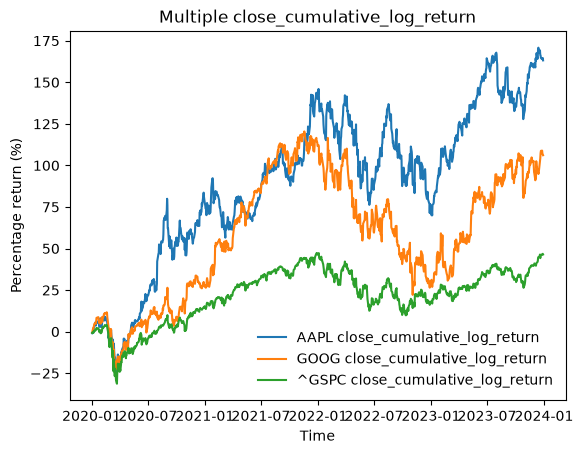

In [29]:
multiplot_dataframe(df,tickers,'close_cumulative_log_return',display_percentage=True)
# multiplot_dataframe(df_crypto,tickers_crypto,'close_cumulative_log_return',display_percentage=True)

In [ ]:
# Time horizon for the time series 
max_lags = 4 
# Forecast horizon 
forecast_horizon = 1 
# Sharpe annualized rate 
annualized_rate = np.sqrt(252)
annualized_rate_crypto = np.sqrt(365)

## Setup the Neural Network 